In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import responses
from responses import matchers

from epicsarchiver.common.base_archiver import DEFAULT_RETRIEVAL_PORT
from epicsarchiver.retrieval.EPICSEvent_pb2 import SCALAR_INT, PayloadInfo
from tests.retrieval.fake_data import TEST_EVENTS, create_pb_bytes

_host = "archiver.example.org"
_pv = "mypv"

_rsps = responses.RequestsMock()
_rsps.add(
    responses.GET,
    f"http://{_host}:{DEFAULT_RETRIEVAL_PORT}/retrieval/data/getData.raw",
    body=create_pb_bytes(TEST_EVENTS, PayloadInfo(type=SCALAR_INT, pvname=_pv, year=2018)),
    status=200,
    match=[
        matchers.query_string_matcher(
            f"pv={_pv}&from=2018-08-25T17%3A45%3A00.000000Z&"
            "to=2018-08-25T18%3A45%3A00.000000Z"
        )
    ],
)
_rsps.start()

In [3]:
import polars as pl
import matplotlib.pyplot as plt

from epicsarchiver.retrieval.client.archiver_retrieval import ArchiverRetrieval

%matplotlib inline

In [4]:
archiver = ArchiverRetrieval("archiver.example.org")
df = archiver.get_data("mypv", "20180825 17:45", "20180825 18:45")

In [5]:
_rsps.stop()
_rsps.reset()

In [6]:
df.head()

date,pv,val,severity,status,field_values,headers
"datetime[ns, UTC]",str,i64,i32,i32,list[struct[2]],list[struct[2]]
2018-09-18 20:26:23.931598267 UTC,"""mypv""",1,0,0,"[{""hey"",""ho""}]",[]
2018-09-18 20:26:24.907631989 UTC,"""mypv""",2,0,0,"[{""hey"",""ho""}]",[]
2018-09-18 20:26:25.931598267 UTC,"""mypv""",3,0,0,"[{""hey"",""ho""}]",[]
2018-09-18 20:26:26.911606448 UTC,"""mypv""",4,0,0,"[{""hey"",""ho""}]",[]


In [7]:
df.describe()

statistic,date,pv,val,severity,status,field_values,headers
str,str,str,f64,f64,f64,f64,f64
"""count""","""4""","""4""",4.0,4.0,4.0,4.0,4.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0
"""mean""","""2018-09-18 20:26:25.420609+00:…",null,2.5,0.0,0.0,null,null
"""std""",null,null,1.290994,0.0,0.0,null,null
"""min""","""2018-09-18 20:26:23.931598+00:…","""mypv""",1.0,0.0,0.0,null,null
"""25%""","""2018-09-18 20:26:24.907631+00:…",null,2.0,0.0,0.0,null,null
"""50%""","""2018-09-18 20:26:25.931598+00:…",null,3.0,0.0,0.0,null,null
"""75%""","""2018-09-18 20:26:25.931598+00:…",null,3.0,0.0,0.0,null,null
"""max""","""2018-09-18 20:26:26.911606+00:…","""mypv""",4.0,0.0,0.0,null,null


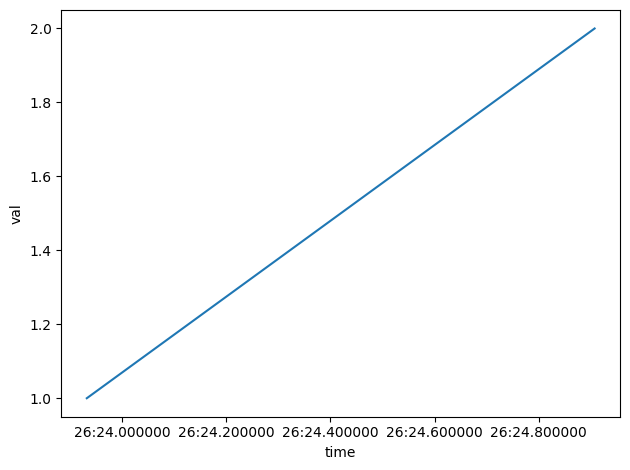

In [8]:
df_filtered = df.head(2)

plt.plot(df_filtered["date"].to_list(), df_filtered["val"].to_list())
plt.xlabel("time")
plt.ylabel("val")
plt.tight_layout()
# NBVAL_IGNORE_OUTPUT